# EDA y Limpieza de Datos — NYC Yellow Taxi 2026-01

**Tarea 1 — Sistemas Urbanos Inteligentes (ICT3115, 2026-1)**  
**Problema:** Estimación de tiempo de viaje (Regresión)  
**Autores:** Nicolás Herrera y Vincent Metzker

Este notebook cubre:
1. Carga de datos desde Parquet
2. Análisis exploratorio (distribuciones, nulos, outliers)
3. Limpieza y filtrado
4. Feature engineering (temporal, geoespacial)
5. Exportación de dos versiones del dataset:
   - `trips_with_cats.parquet` — incluye variables categóricas (is_weekend, is_rush_hour, etc.)
   - `trips_numeric_only.parquet` — solo variables numéricas continuas

## 0. Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pyarrow.parquet as pq
import warnings
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

SEED = 22041991
np.random.seed(SEED)

DATA_DIR = '../data'
OUT_DIR  = '../data'
PARQUET_FILE = os.path.join(DATA_DIR, 'yellow_tripdata_2026-01.parquet')
print('Parquet encontrado:', os.path.exists(PARQUET_FILE))

Parquet encontrado: True


In [2]:
import os
print(f"Current Directory: {os.getcwd()}")
print(f"Directory Contents: {os.listdir('.')}")

Current Directory: c:\Users\nicol\OneDrive\Documents\GitHub\tarea-1-sistemas-urbanos\notebooks
Directory Contents: ['01_eda_limpieza.ipynb']


## 1. Carga de datos

In [3]:
trips = pq.read_table(PARQUET_FILE).to_pandas()
print(f'Shape original: {trips.shape}')
trips.head(3)

Shape original: (3724889, 20)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0000,0.9700,1.0000,N,239,238,1,7.2000,1.0000,0.5000,3.6600,0.0000,1.0000,15.8600,2.5000,0.0000,0.0000
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0000,0.9000,1.0000,N,163,162,2,7.9000,4.2500,0.5000,0.0000,0.0000,1.0000,13.6500,2.5000,0.0000,0.7500
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0000,1.4000,1.0000,N,43,237,1,10.7000,4.2500,0.5000,2.5000,0.0000,1.0000,18.9500,2.5000,0.0000,0.7500


In [4]:
trips.dtypes

VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag                  str
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
cbd_congestion_fee              float64
dtype: object

## 2. Análisis Exploratorio

### 2.1 Estadísticas descriptivas

In [5]:
trips.describe(include='all')

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
count,3724889.0000,3724889,3724889,2636831.0000,3724889.0000,2636831.0000,2636831,3724889.0000,3724889.0000,3724889.0000,3724889.0000,3724889.0000,3724889.0000,3724889.0000,3724889.0000,3724889.0000,3724889.0000,2636831.0000,2636831.0000,3724889.0000
unique,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,2634494,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1.8736,2026-01-17 01:44:52.106518,2026-01-17 02:02:03.696138,1.2563,6.4556,5.2189,NaN,161.4372,160.9936,0.8466,20.8043,1.0231,0.4834,2.6081,0.4984,0.9479,29.1785,2.1549,0.1483,0.5196
min,1.0000,2025-12-31 23:57:29,2025-12-31 23:57:32,0.0000,0.0000,1.0000,NaN,1.0000,1.0000,0.0000,-2555.2000,-7.5000,-0.5000,-88.8800,-94.5000,-1.0000,-2560.2000,-2.5000,-1.7500,-0.7500
25%,2.0000,2026-01-09 17:51:59,2026-01-09 18:08:47,1.0000,1.0000,1.0000,NaN,114.0000,107.0000,0.0000,10.0000,0.0000,0.5000,0.0000,0.0000,1.0000,17.0000,2.5000,0.0000,0.0000
50%,2.0000,2026-01-16 21:20:56,2026-01-16 21:36:14,1.0000,1.8100,1.0000,NaN,161.0000,162.0000,1.0000,15.6000,0.0000,0.5000,2.0000,0.0000,1.0000,23.0500,2.5000,0.0000,0.7500
75%,2.0000,2026-01-24 07:25:11,2026-01-24 07:40:22,1.0000,3.7300,1.0000,NaN,233.0000,234.0000,1.0000,26.1000,2.5000,0.5000,3.7100,0.0000,1.0000,33.8300,2.5000,0.0000,0.7500
max,7.0000,2026-02-01 00:45:01,2026-02-01 23:35:31,9.0000,269097.4800,99.0000,NaN,265.0000,265.0000,4.0000,2555.2000,17.4600,4.7500,766.0000,122.2200,1.0000,2560.2000,2.5000,26.7500,0.7500


### 2.2 Valores nulos

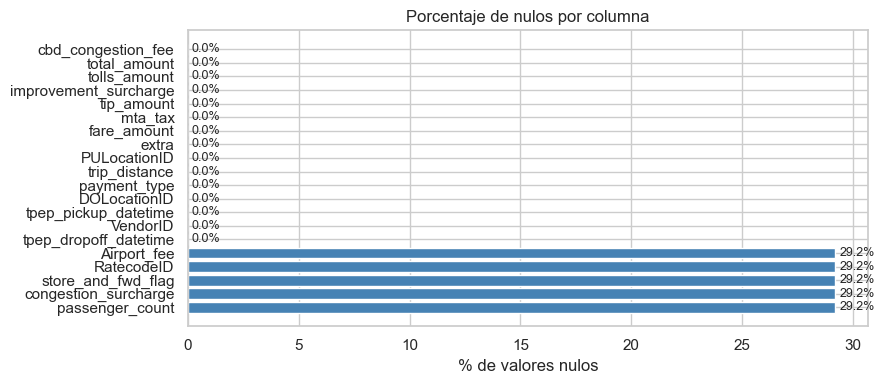

,nulos,pct_%
passenger_count,1088058,29.2100
congestion_surcharge,1088058,29.2100
store_and_fwd_flag,1088058,29.2100
RatecodeID,1088058,29.2100
Airport_fee,1088058,29.2100
tpep_dropoff_datetime,0,0.0000
VendorID,0,0.0000
tpep_pickup_datetime,0,0.0000
DOLocationID,0,0.0000
payment_type,0,0.0000


In [6]:
null_info = pd.DataFrame({
    'nulos': trips.isnull().sum(),
    'pct_%': (trips.isnull().mean() * 100).round(2)
}).sort_values('pct_%', ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(null_info.index, null_info['pct_%'], color='steelblue')
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
ax.set_xlabel('% de valores nulos')
ax.set_title('Porcentaje de nulos por columna')
plt.tight_layout()
plt.show()

null_info

### 2.3 Distribución de variables numéricas clave

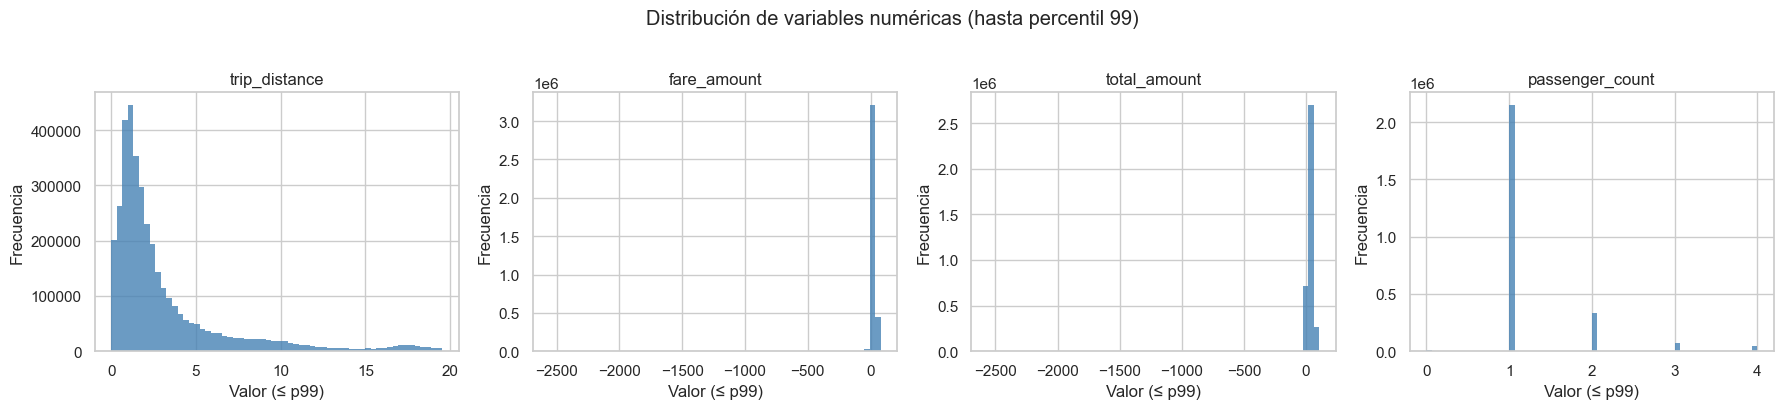

In [7]:
num_cols = ['trip_distance', 'fare_amount', 'total_amount', 'passenger_count']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, num_cols):
    # Clip extremos para visualización
    data = trips[col].dropna()
    q99 = data.quantile(0.99)
    ax.hist(data[data <= q99], bins=60, color='steelblue', edgecolor='none', alpha=0.8)
    ax.set_title(col)
    ax.set_xlabel('Valor (≤ p99)')
    ax.set_ylabel('Frecuencia')
plt.suptitle('Distribución de variables numéricas (hasta percentil 99)', y=1.02)
plt.tight_layout()
plt.show()

### 2.4 Distribución temporal

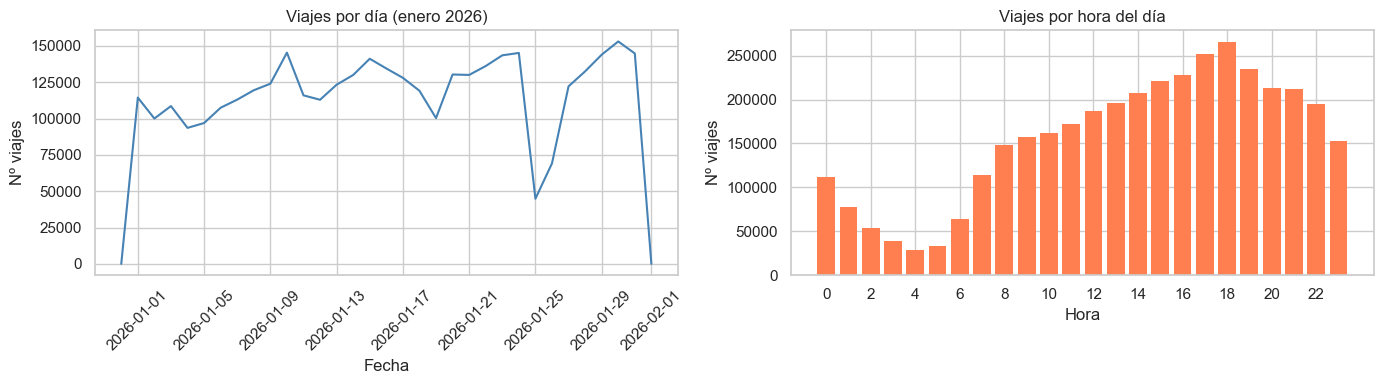

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Viajes por día
daily = trips['tpep_pickup_datetime'].dt.date.value_counts().sort_index()
axes[0].plot(daily.index, daily.values, color='steelblue', lw=1.5)
axes[0].set_title('Viajes por día (enero 2026)')
axes[0].set_xlabel('Fecha')
axes[0].set_ylabel('Nº viajes')
axes[0].tick_params(axis='x', rotation=45)

# Viajes por hora del día
hourly = trips['tpep_pickup_datetime'].dt.hour.value_counts().sort_index()
axes[1].bar(hourly.index, hourly.values, color='coral', edgecolor='none')
axes[1].set_title('Viajes por hora del día')
axes[1].set_xlabel('Hora')
axes[1].set_ylabel('Nº viajes')
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

### 2.5 Variables categóricas

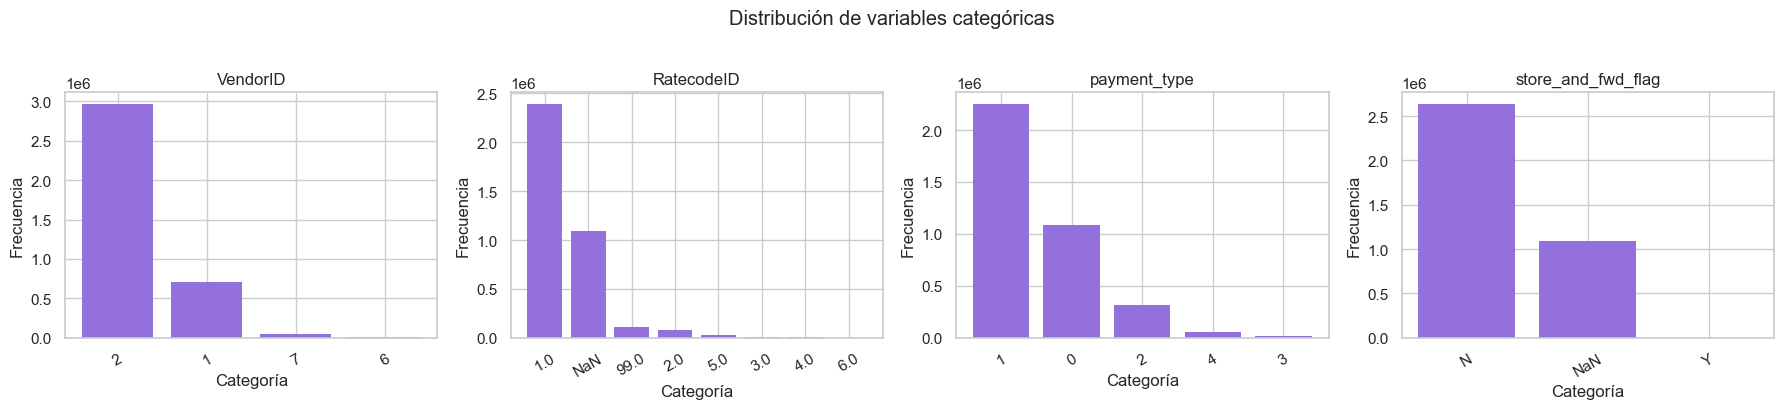

In [10]:
cat_cols = ['VendorID', 'RatecodeID', 'payment_type', 'store_and_fwd_flag']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, cat_cols):
    vc = trips[col].value_counts(dropna=False)
    labels = [str(i) if i is not None and str(i) != 'nan' else 'NaN' for i in vc.index]
    ax.bar(labels, vc.values, color='mediumpurple', edgecolor='none')
    ax.set_title(col)
    ax.set_xlabel('Categoría')
    ax.set_ylabel('Frecuencia')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Distribución de variables categóricas', y=1.02)
plt.tight_layout()
plt.show()

### 2.6 Top zonas de pickup y dropoff

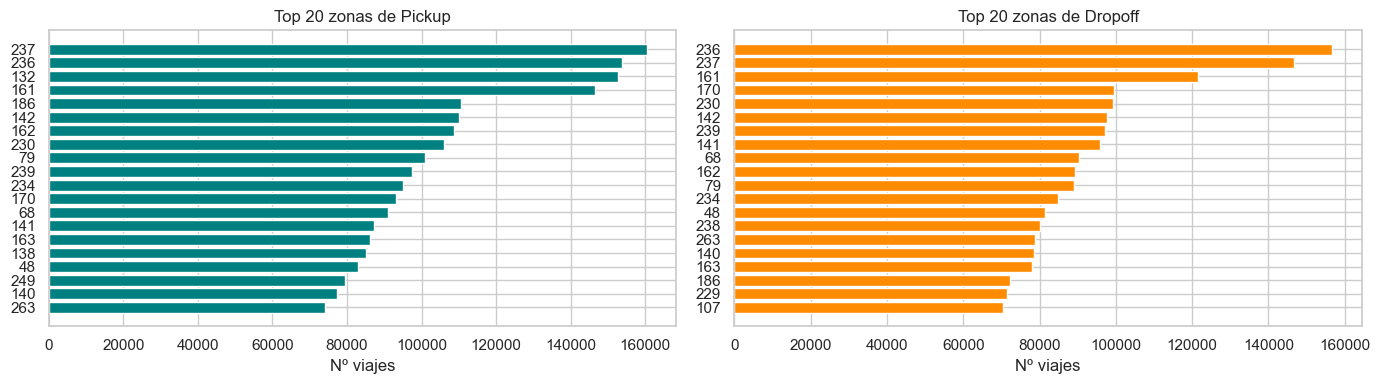

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

top_pu = trips['PULocationID'].value_counts().head(20)
axes[0].barh(top_pu.index.astype(str), top_pu.values, color='teal')
axes[0].set_title('Top 20 zonas de Pickup')
axes[0].set_xlabel('Nº viajes')
axes[0].invert_yaxis()

top_do = trips['DOLocationID'].value_counts().head(20)
axes[1].barh(top_do.index.astype(str), top_do.values, color='darkorange')
axes[1].set_title('Top 20 zonas de Dropoff')
axes[1].set_xlabel('Nº viajes')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 3. Variable objetivo — `trip_duration`

In [12]:
trips['trip_duration'] = (
    trips['tpep_dropoff_datetime'] - trips['tpep_pickup_datetime']
).dt.total_seconds() / 60.0

print('Estadísticas de trip_duration (minutos) ANTES de limpiar:')
print(trips['trip_duration'].describe())

Estadísticas de trip_duration (minutos) ANTES de limpiar:
count   3724889.0000
mean         17.1932
std          25.1780
min         -11.7000
25%           8.0667
50%          13.3667
75%          21.2000
max        7507.9000
Name: trip_duration, dtype: float64


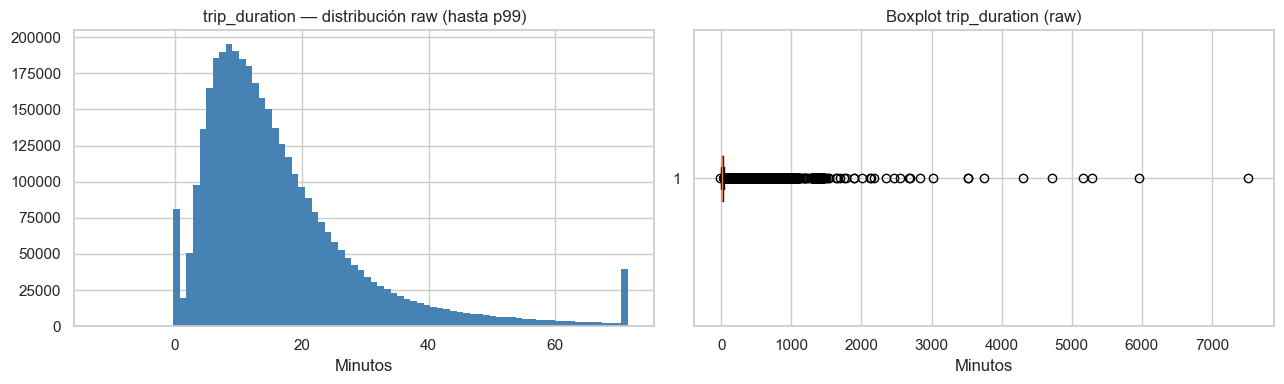

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Raw (hasta p99)
q99 = trips['trip_duration'].quantile(0.99)
axes[0].hist(trips['trip_duration'].clip(upper=q99), bins=80, color='steelblue', edgecolor='none')
axes[0].set_title('trip_duration — distribución raw (hasta p99)')
axes[0].set_xlabel('Minutos')

# Boxplot
axes[1].boxplot(trips['trip_duration'].dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[1].set_title('Boxplot trip_duration (raw)')
axes[1].set_xlabel('Minutos')

plt.tight_layout()
plt.show()

## 4. Limpieza de datos

### 4.1 Selección de columnas relevantes

In [14]:
COLS_KEEP = [
    # Identificadores categóricos
    'VendorID', 'RatecodeID', 'payment_type', 'store_and_fwd_flag',
    # Ubicación
    'PULocationID', 'DOLocationID',
    # Numéricas
    'passenger_count', 'trip_distance', 'fare_amount', 'total_amount',
    'tip_amount', 'tolls_amount',
    # Temporales (para feature engineering)
    'tpep_pickup_datetime',
    # Target
    'trip_duration',
]

df = trips[COLS_KEEP].copy()
print(f'Shape tras selección: {df.shape}')

Shape tras selección: (3724889, 14)


### 4.2 Eliminar duplicados

In [15]:
n_before = len(df)
df.drop_duplicates(inplace=True)
print(f'Duplicados eliminados: {n_before - len(df):,} → shape: {df.shape}')

Duplicados eliminados: 0 → shape: (3724889, 14)


### 4.3 Manejo de nulos

In [16]:
# store_and_fwd_flag: rellenar con 'N' (más frecuente)
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].fillna('N')

# passenger_count: mediana (es discreta, con nulos ~29%)
median_pass = df['passenger_count'].median()
df['passenger_count'] = df['passenger_count'].fillna(median_pass)

# RatecodeID: moda
mode_rate = df['RatecodeID'].mode()[0]
df['RatecodeID'] = df['RatecodeID'].fillna(mode_rate)

print('Nulos restantes:')
print(df.isnull().sum())

Nulos restantes:
VendorID                0
RatecodeID              0
payment_type            0
store_and_fwd_flag      0
PULocationID            0
DOLocationID            0
passenger_count         0
trip_distance           0
fare_amount             0
total_amount            0
tip_amount              0
tolls_amount            0
tpep_pickup_datetime    0
trip_duration           0
dtype: int64


### 4.4 Filtros de lógica de negocio

In [ ]:
n0 = len(df)

# Solo enero 2026 estricto
df = df[df['tpep_pickup_datetime'].dt.year == 2026]
df = df[df['tpep_pickup_datetime'].dt.month == 1]
print(f'Filtro mes/año: -{n0 - len(df):,} filas → {len(df):,}')

n1 = len(df)
# Duración razonable: 1 min ≤ trip_duration ≤ 120 min
df = df[(df['trip_duration'] >= 1) & (df['trip_duration'] <= 120)]
print(f'Filtro duración [1, 120] min: -{n1 - len(df):,} filas → {len(df):,}')

n2 = len(df)
# Distancia razonable: 0.1 ≤ trip_distance ≤ 100 millas
df = df[(df['trip_distance'] >= 0.1) & (df['trip_distance'] <= 100)]
print(f'Filtro distancia [0.1, 100] mi: -{n2 - len(df):,} filas → {len(df):,}')

n3 = len(df)
# Montos positivos
df = df[(df['fare_amount'] > 0) & (df['total_amount'] > 0)]
print(f'Filtro montos > 0: -{n3 - len(df):,} filas → {len(df):,}')

n4 = len(df)
# Pasajeros 1-8
df = df[(df['passenger_count'] >= 1) & (df['passenger_count'] <= 8)]
print(f'Filtro pasajeros [1,8]: -{n4 - len(df):,} filas → {len(df):,}')

# LocationIDs válidos (1-265 según TLC)
n5 = len(df)
df = df[(df['PULocationID'].between(1, 265)) & (df['DOLocationID'].between(1, 265))]
print(f'Filtro LocationIDs válidos: -{n5 - len(df):,} filas → {len(df):,}')

# RatecodeID válido (1-6)
#n6 = len(df)
#df = df[df['RatecodeID'].between(1, 6)]
#print(f'Filtro RatecodeID [1,6]: -{n6 - len(df):,} filas → {len(df):,}')

print(f'\nRegistros totales tras limpieza: {len(df):,} ({len(df)/n0*100:.1f}% del original)')

Filtro mes/año: -7 filas → 3,724,882
Filtro duración [1, 120] min: -88,268 filas → 3,636,614
Filtro distancia [0.1, 100] mi: -122,019 filas → 3,514,595
Filtro montos > 0: -35,550 filas → 3,479,045
Filtro pasajeros [1,8]: -14,150 filas → 3,464,895
Filtro LocationIDs válidos: -0 filas → 3,464,895
Filtro RatecodeID [1,6]: -107,017 filas → 3,357,878

Registros totales tras limpieza: 3,357,878 (90.1% del original)


### 4.5 Eliminar outliers con IQR sobre target y distancia

In [18]:
def iqr_filter(df, col, factor=3.0):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    mask = df[col].between(lower, upper)
    print(f'  {col}: [{lower:.2f}, {upper:.2f}] → eliminados {(~mask).sum():,}')
    return df[mask]

print('Outliers IQR (factor=3):')
n_pre = len(df)
df = iqr_filter(df, 'trip_duration')
df = iqr_filter(df, 'trip_distance')
df = iqr_filter(df, 'fare_amount')
print(f'  Total eliminados: {n_pre - len(df):,} → {len(df):,} registros finales')

Outliers IQR (factor=3):
  trip_duration: [-28.53, 57.22] → eliminados 36,993
  trip_distance: [-6.33, 10.96] → eliminados 159,446
  fare_amount: [-30.42, 62.26] → eliminados 19,341
  Total eliminados: 215,780 → 3,142,098 registros finales


### 4.6 Distribución de la variable objetivo tras limpieza

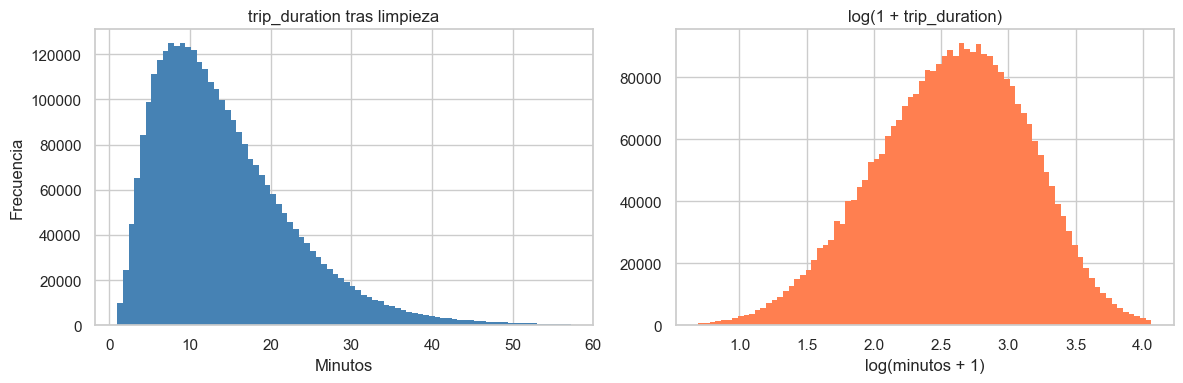

count   3142098.0000
mean         14.2652
std           8.4801
min           1.0000
25%           7.9333
50%          12.5167
75%          18.7667
max          57.2000
Name: trip_duration, dtype: float64


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['trip_duration'], bins=80, color='steelblue', edgecolor='none')
axes[0].set_title('trip_duration tras limpieza')
axes[0].set_xlabel('Minutos')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(np.log1p(df['trip_duration']), bins=80, color='coral', edgecolor='none')
axes[1].set_title('log(1 + trip_duration)')
axes[1].set_xlabel('log(minutos + 1)')

plt.tight_layout()
plt.show()

print(df['trip_duration'].describe())

## 4.7 Join con metadata de borough (Census ACS)

In [20]:
# ── Cargar lookup enriquecido ─────────────────────────────────────────────────
lookup = pd.read_csv(os.path.join(DATA_DIR, 'taxi_zone_lookup_enriched.csv'))

# ── Preparar versiones PU y DO ────────────────────────────────────────────────
# Dropear Zone y service_zone (demasiado granular para el modelo)
drop_cols = ['Zone', 'service_zone']

pu_lookup = (lookup
    .drop(columns=drop_cols, errors='ignore')
    .add_prefix("PU_")
    .rename(columns={"PU_LocationID": "PULocationID"}))

do_lookup = (lookup
    .drop(columns=drop_cols, errors='ignore')
    .add_prefix("DO_")
    .rename(columns={"DO_LocationID": "DOLocationID"}))

# ── Join ──────────────────────────────────────────────────────────────────────
df = df.merge(pu_lookup, on="PULocationID", how="left")
df = df.merge(do_lookup, on="DOLocationID", how="left")

# ── Codificar Borough como entero (para embeddings) ───────────────────────────
BOROUGH_MAP = {'Manhattan': 0, 'Brooklyn': 1, 'Queens': 2,
               'Bronx': 3, 'Staten Island': 4, 'EWR': 5}
# Unknown / NaN → 6

df['PU_Borough_id'] = df['PU_Borough'].map(BOROUGH_MAP).fillna(6).astype(np.int8)
df['DO_Borough_id'] = df['DO_Borough'].map(BOROUGH_MAP).fillna(6).astype(np.int8)
df.drop(columns=['PU_Borough', 'DO_Borough'], inplace=True)

# ── Rellenar nulos de census (EWR / Unknown no tienen datos → 0) ──────────────
census_cols = [c for c in df.columns if c.startswith(('PU_', 'DO_'))
               and c not in ('PU_Borough_id', 'DO_Borough_id')]
df[census_cols] = df[census_cols].fillna(0)

print(f'Shape tras join: {df.shape}')
print('Columnas census agregadas:')
print([c for c in df.columns if c.startswith(('PU_', 'DO_'))])

Shape tras join: (3142098, 36)
Columnas census agregadas:
['PU_Population', 'PU_MedianHouseholdIncome', 'PU_HousingUnits', 'PU_Transport_CarAlone_pct', 'PU_Transport_Carpool_pct', 'PU_Transport_PublicTransit_pct', 'PU_Transport_Walked_pct', 'PU_Transport_Bicycle_pct', 'PU_Transport_Other_pct', 'PU_Transport_WorkFromHome_pct', 'DO_Population', 'DO_MedianHouseholdIncome', 'DO_HousingUnits', 'DO_Transport_CarAlone_pct', 'DO_Transport_Carpool_pct', 'DO_Transport_PublicTransit_pct', 'DO_Transport_Walked_pct', 'DO_Transport_Bicycle_pct', 'DO_Transport_Other_pct', 'DO_Transport_WorkFromHome_pct', 'PU_Borough_id', 'DO_Borough_id']


## 5. Feature Engineering

### 5.1 Variables temporales

In [21]:
dt = df['tpep_pickup_datetime'].dt

df['hour']        = dt.hour.astype(np.int8)          # 0-23
df['day_of_week'] = dt.dayofweek.astype(np.int8)     # 0=Lun ... 6=Dom
df['month']       = dt.month.astype(np.int8)          # 1=Ene
df['day_of_month']= dt.day.astype(np.int8)

# Variables categóricas binarias / ordinales derivadas
df['is_weekend']   = (df['day_of_week'] >= 5).astype(np.int8)  # Sab/Dom
df['is_rush_hour'] = df['hour'].apply(
    lambda h: 1 if (7 <= h <= 9) or (16 <= h <= 19) else 0
).astype(np.int8)
df['is_night']     = ((df['hour'] >= 22) | (df['hour'] < 6)).astype(np.int8)
df['is_morning']   = ((df['hour'] >= 6) & (df['hour'] < 12)).astype(np.int8)
df['is_afternoon'] = ((df['hour'] >= 12) & (df['hour'] < 18)).astype(np.int8)

# Encodings cíclicos para hora y día (útiles para MLP base)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24).astype(np.float32)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24).astype(np.float32)
df['dow_sin']  = np.sin(2 * np.pi * df['day_of_week'] / 7).astype(np.float32)
df['dow_cos']  = np.cos(2 * np.pi * df['day_of_week'] / 7).astype(np.float32)

print('Features temporales creadas:')
temporal_cols = ['hour','day_of_week','month','day_of_month',
                 'is_weekend','is_rush_hour','is_night','is_morning','is_afternoon',
                 'hour_sin','hour_cos','dow_sin','dow_cos']
print(df[temporal_cols].head())

Features temporales creadas:
   hour  day_of_week  month  day_of_month  is_weekend  is_rush_hour  is_night  \
0     0            3      1             1           0             0         1   
1     0            3      1             1           0             0         1   
2     0            3      1             1           0             0         1   
3     0            3      1             1           0             0         1   
4     0            3      1             1           0             0         1   

   is_morning  is_afternoon  hour_sin  hour_cos  dow_sin  dow_cos  
0           0             0    0.0000    1.0000   0.4339  -0.9010  
1           0             0    0.0000    1.0000   0.4339  -0.9010  
2           0             0    0.0000    1.0000   0.4339  -0.9010  
3           0             0    0.0000    1.0000   0.4339  -0.9010  
4           0             0    0.0000    1.0000   0.4339  -0.9010  


### 5.2 Visualización de variables temporales derivadas

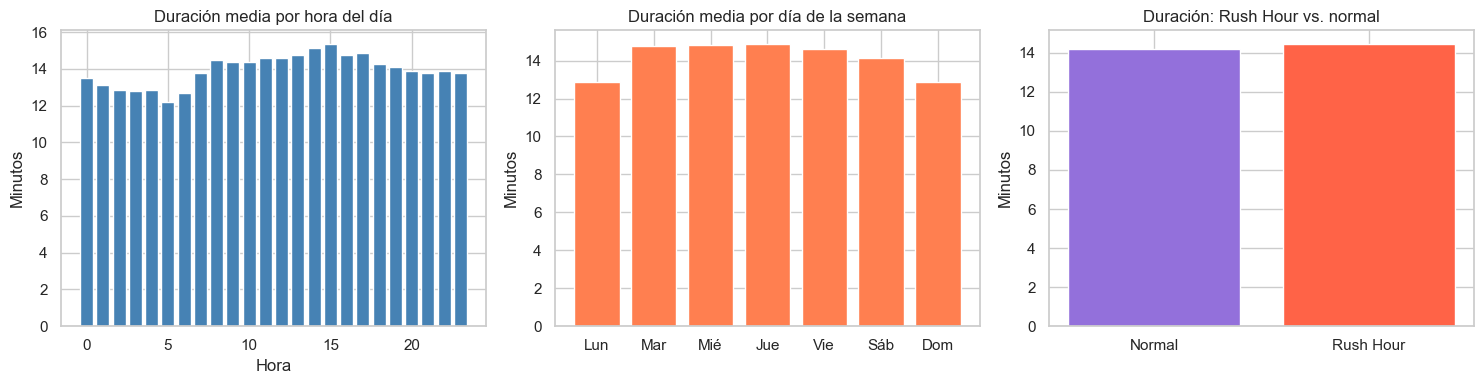

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Duración media por hora
mean_by_hour = df.groupby('hour')['trip_duration'].mean()
axes[0].bar(mean_by_hour.index, mean_by_hour.values, color='steelblue')
axes[0].set_title('Duración media por hora del día')
axes[0].set_xlabel('Hora')
axes[0].set_ylabel('Minutos')

# Duración media por día de la semana
dias = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
mean_by_dow = df.groupby('day_of_week')['trip_duration'].mean()
axes[1].bar(dias, mean_by_dow.values, color='coral')
axes[1].set_title('Duración media por día de la semana')
axes[1].set_ylabel('Minutos')

# Rush hour vs. no rush
rush_comp = df.groupby('is_rush_hour')['trip_duration'].mean()
axes[2].bar(['Normal', 'Rush Hour'], rush_comp.values, color=['mediumpurple','tomato'])
axes[2].set_title('Duración: Rush Hour vs. normal')
axes[2].set_ylabel('Minutos')

plt.tight_layout()
plt.show()

### 5.3 Codificación de categóricas para el modelo

In [23]:
# store_and_fwd_flag: N→0, Y→1
df['store_and_fwd_flag'] = (df['store_and_fwd_flag'] == 'Y').astype(np.int8)

# Tipos enteros para categóricas
df['VendorID']     = df['VendorID'].astype(np.int8)
df['RatecodeID']   = df['RatecodeID'].astype(np.int8)
df['payment_type'] = df['payment_type'].astype(np.int8)

# PU/DOLocationID como int16
df['PULocationID'] = df['PULocationID'].astype(np.int16)
df['DOLocationID'] = df['DOLocationID'].astype(np.int16)

print('Tipos de dato actualizados:')
print(df.dtypes)

Tipos de dato actualizados:
VendorID                                    int8
RatecodeID                                  int8
payment_type                                int8
store_and_fwd_flag                          int8
PULocationID                               int16
DOLocationID                               int16
passenger_count                          float64
trip_distance                            float64
fare_amount                              float64
total_amount                             float64
tip_amount                               float64
tolls_amount                             float64
tpep_pickup_datetime              datetime64[us]
trip_duration                            float64
PU_Population                            float64
PU_MedianHouseholdIncome                 float64
PU_HousingUnits                          float64
PU_Transport_CarAlone_pct                float64
PU_Transport_Carpool_pct                 float64
PU_Transport_PublicTransit_pct           

## 6. Correlaciones

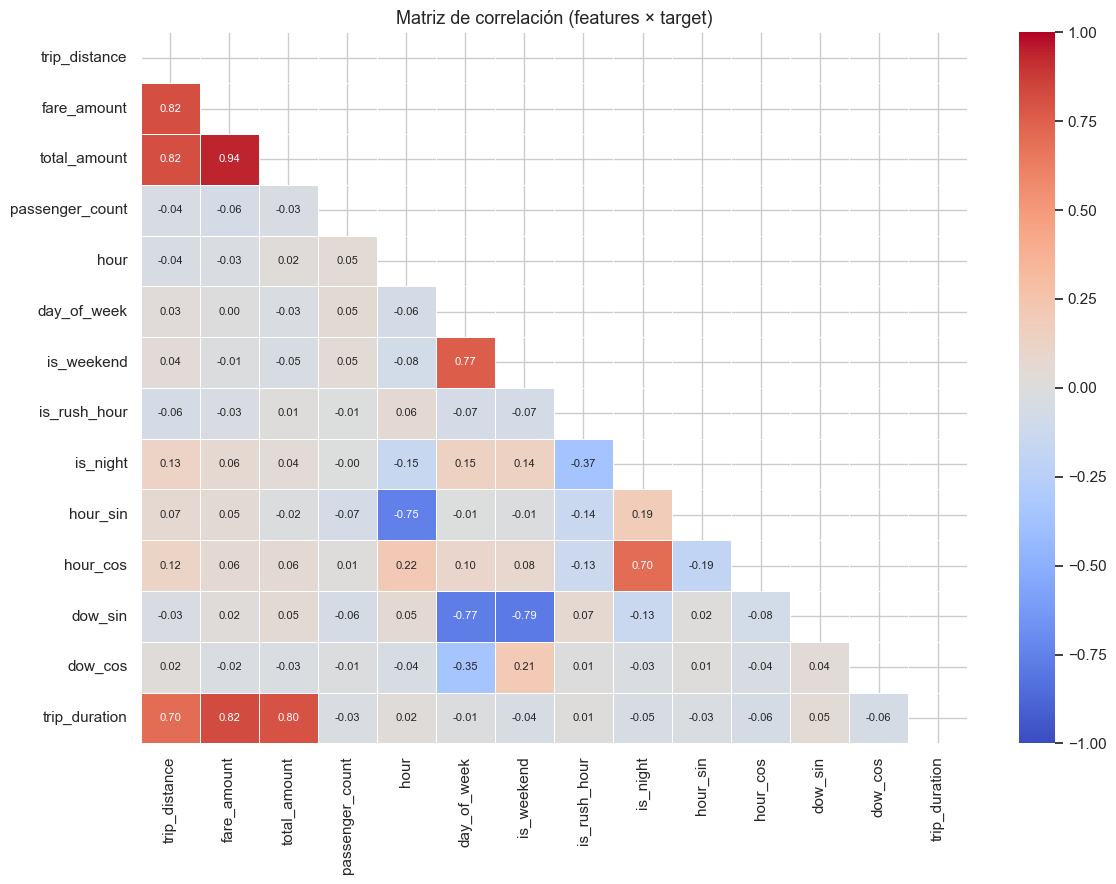

In [24]:
numeric_for_corr = [
    'trip_distance','fare_amount','total_amount','passenger_count',
    'hour','day_of_week','is_weekend','is_rush_hour','is_night',
    'hour_sin','hour_cos','dow_sin','dow_cos',
    'trip_duration'
]
corr = df[numeric_for_corr].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0, ax=ax, linewidths=0.5, annot_kws={'size': 8})
ax.set_title('Matriz de correlación (features × target)', fontsize=13)
plt.tight_layout()
plt.show()

### Correlaciones con `trip_duration` (ordenadas)

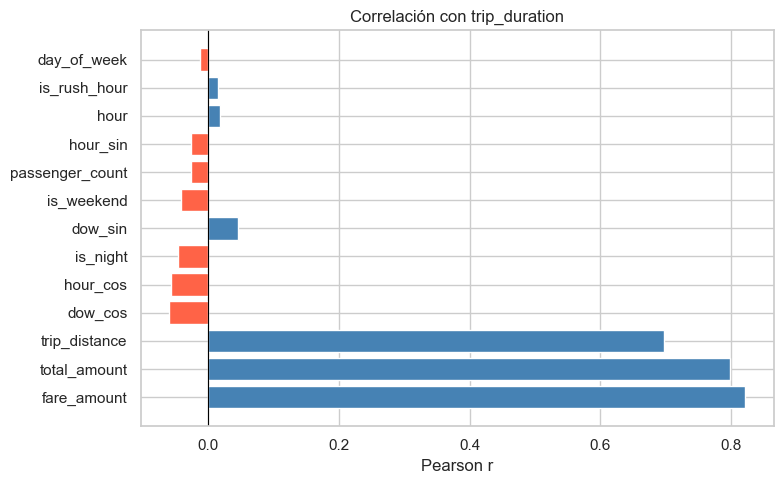

In [25]:
target_corr = corr['trip_duration'].drop('trip_duration').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['tomato' if v < 0 else 'steelblue' for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Correlación con trip_duration')
ax.set_xlabel('Pearson r')
plt.tight_layout()
plt.show()

## 7. Exportar versiones del dataset

### 7.1 Definición de columnas por versión

In [26]:
# ── Columnas numéricas continuas (disponibles en AMBAS versiones) ─────────────
NUM_COLS = [
    'trip_distance',
    'fare_amount',
    'total_amount',
    'tip_amount',
    'tolls_amount',
    'passenger_count',
    # Cíclicas (sin/cos)
    'hour_sin', 'hour_cos',
    'dow_sin',  'dow_cos',
    # Census ACS — nivel borough (PU)
    'PU_Population', 'PU_MedianHouseholdIncome', 'PU_HousingUnits',
    'PU_Transport_CarAlone_pct', 'PU_Transport_Carpool_pct',
    'PU_Transport_PublicTransit_pct', 'PU_Transport_Walked_pct',
    'PU_Transport_Bicycle_pct', 'PU_Transport_Other_pct',
    'PU_Transport_WorkFromHome_pct',
    # Census ACS — nivel borough (DO)
    'DO_Population', 'DO_MedianHouseholdIncome', 'DO_HousingUnits',
    'DO_Transport_CarAlone_pct', 'DO_Transport_Carpool_pct',
    'DO_Transport_PublicTransit_pct', 'DO_Transport_Walked_pct',
    'DO_Transport_Bicycle_pct', 'DO_Transport_Other_pct',
    'DO_Transport_WorkFromHome_pct',
]

# ── Columnas categóricas / binarias (solo en versión CON cats) ─────────────────
CAT_COLS = [
    'VendorID',
    'RatecodeID',
    'payment_type',
    'store_and_fwd_flag',
    'PULocationID',
    'DOLocationID',
    'PU_Borough_id',
    'DO_Borough_id',
    # Derivadas temporales ordinales/binarias
    'hour',
    'day_of_week',
    'month',
    'day_of_month',
    'is_weekend',
    'is_rush_hour',
    'is_night',
    'is_morning',
    'is_afternoon',
]

TARGET = 'trip_duration'

# Eliminar datetime (ya no lo necesitamos)
df_clean = df.drop(columns=['tpep_pickup_datetime'])

print(f'Filas finales: {len(df_clean):,}')
print(f'Cols numéricas ({len(NUM_COLS)}): {NUM_COLS}')
print(f'Cols categóricas ({len(CAT_COLS)}): {CAT_COLS}')
print(f'Target: {TARGET}')

Filas finales: 3,142,098
Cols numéricas (30): ['trip_distance', 'fare_amount', 'total_amount', 'tip_amount', 'tolls_amount', 'passenger_count', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'PU_Population', 'PU_MedianHouseholdIncome', 'PU_HousingUnits', 'PU_Transport_CarAlone_pct', 'PU_Transport_Carpool_pct', 'PU_Transport_PublicTransit_pct', 'PU_Transport_Walked_pct', 'PU_Transport_Bicycle_pct', 'PU_Transport_Other_pct', 'PU_Transport_WorkFromHome_pct', 'DO_Population', 'DO_MedianHouseholdIncome', 'DO_HousingUnits', 'DO_Transport_CarAlone_pct', 'DO_Transport_Carpool_pct', 'DO_Transport_PublicTransit_pct', 'DO_Transport_Walked_pct', 'DO_Transport_Bicycle_pct', 'DO_Transport_Other_pct', 'DO_Transport_WorkFromHome_pct']
Cols categóricas (17): ['VendorID', 'RatecodeID', 'payment_type', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'PU_Borough_id', 'DO_Borough_id', 'hour', 'day_of_week', 'month', 'day_of_month', 'is_weekend', 'is_rush_hour', 'is_night', 'is_morning', 'is_afternoon'

### 7.2 Versión CON variables categóricas

In [27]:
df_with_cats = df_clean[NUM_COLS + CAT_COLS + [TARGET]].copy()
print(f'df_with_cats shape: {df_with_cats.shape}')
print('Columnas:', list(df_with_cats.columns))
df_with_cats.head(3)

df_with_cats shape: (3142098, 48)
Columnas: ['trip_distance', 'fare_amount', 'total_amount', 'tip_amount', 'tolls_amount', 'passenger_count', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'PU_Population', 'PU_MedianHouseholdIncome', 'PU_HousingUnits', 'PU_Transport_CarAlone_pct', 'PU_Transport_Carpool_pct', 'PU_Transport_PublicTransit_pct', 'PU_Transport_Walked_pct', 'PU_Transport_Bicycle_pct', 'PU_Transport_Other_pct', 'PU_Transport_WorkFromHome_pct', 'DO_Population', 'DO_MedianHouseholdIncome', 'DO_HousingUnits', 'DO_Transport_CarAlone_pct', 'DO_Transport_Carpool_pct', 'DO_Transport_PublicTransit_pct', 'DO_Transport_Walked_pct', 'DO_Transport_Bicycle_pct', 'DO_Transport_Other_pct', 'DO_Transport_WorkFromHome_pct', 'VendorID', 'RatecodeID', 'payment_type', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'PU_Borough_id', 'DO_Borough_id', 'hour', 'day_of_week', 'month', 'day_of_month', 'is_weekend', 'is_rush_hour', 'is_night', 'is_morning', 'is_afternoon', 'trip_duration']


,trip_distance,fare_amount,total_amount,tip_amount,tolls_amount,passenger_count,hour_sin,hour_cos,dow_sin,dow_cos,PU_Population,PU_MedianHouseholdIncome,PU_HousingUnits,PU_Transport_CarAlone_pct,PU_Transport_Carpool_pct,PU_Transport_PublicTransit_pct,PU_Transport_Walked_pct,PU_Transport_Bicycle_pct,PU_Transport_Other_pct,PU_Transport_WorkFromHome_pct,DO_Population,DO_MedianHouseholdIncome,DO_HousingUnits,DO_Transport_CarAlone_pct,DO_Transport_Carpool_pct,DO_Transport_PublicTransit_pct,DO_Transport_Walked_pct,DO_Transport_Bicycle_pct,DO_Transport_Other_pct,DO_Transport_WorkFromHome_pct,VendorID,RatecodeID,payment_type,store_and_fwd_flag,PULocationID,DOLocationID,PU_Borough_id,DO_Borough_id,hour,day_of_week,month,day_of_month,is_weekend,is_rush_hour,is_night,is_morning,is_afternoon,trip_duration
0,0.9700,7.2000,15.8600,3.6600,0.0000,1.0000,0.0000,1.0000,0.4339,-0.9010,1694251.0000,106403.0000,932314.0000,5.2000,1.1000,51.0000,18.3000,3.1000,3.2000,18.1000,1694251.0000,106403.0000,932314.0000,5.2000,1.1000,51.0000,18.3000,3.1000,3.2000,18.1000,2,1,1,0,239,238,0,0,0,3,1,1,0,0,1,0,0,5.5500
1,5.5800,38.7000,55.5600,11.1100,0.0000,4.0000,0.0000,1.0000,0.4339,-0.9010,1694251.0000,106403.0000,932314.0000,5.2000,1.1000,51.0000,18.3000,3.1000,3.2000,18.1000,1694251.0000,106403.0000,932314.0000,5.2000,1.1000,51.0000,18.3000,3.1000,3.2000,18.1000,2,1,1,0,142,209,0,0,0,3,1,1,0,0,1,0,0,42.8000
2,2.3300,14.2000,24.9400,4.9900,0.0000,2.0000,0.0000,1.0000,0.4339,-0.9010,1694251.0000,106403.0000,932314.0000,5.2000,1.1000,51.0000,18.3000,3.1000,3.2000,18.1000,1694251.0000,106403.0000,932314.0000,5.2000,1.1000,51.0000,18.3000,3.1000,3.2000,18.1000,2,1,1,0,144,137,0,0,0,3,1,1,0,0,1,0,0,13.6000


### 7.3 Versión SIN variables categóricas (solo numéricas continuas)

In [28]:
df_numeric = df_clean[NUM_COLS + [TARGET]].copy()
print(f'df_numeric shape: {df_numeric.shape}')
print('Columnas:', list(df_numeric.columns))
df_numeric.head(3)

df_numeric shape: (3142098, 31)
Columnas: ['trip_distance', 'fare_amount', 'total_amount', 'tip_amount', 'tolls_amount', 'passenger_count', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'PU_Population', 'PU_MedianHouseholdIncome', 'PU_HousingUnits', 'PU_Transport_CarAlone_pct', 'PU_Transport_Carpool_pct', 'PU_Transport_PublicTransit_pct', 'PU_Transport_Walked_pct', 'PU_Transport_Bicycle_pct', 'PU_Transport_Other_pct', 'PU_Transport_WorkFromHome_pct', 'DO_Population', 'DO_MedianHouseholdIncome', 'DO_HousingUnits', 'DO_Transport_CarAlone_pct', 'DO_Transport_Carpool_pct', 'DO_Transport_PublicTransit_pct', 'DO_Transport_Walked_pct', 'DO_Transport_Bicycle_pct', 'DO_Transport_Other_pct', 'DO_Transport_WorkFromHome_pct', 'trip_duration']


,trip_distance,fare_amount,total_amount,tip_amount,tolls_amount,passenger_count,hour_sin,hour_cos,dow_sin,dow_cos,PU_Population,PU_MedianHouseholdIncome,PU_HousingUnits,PU_Transport_CarAlone_pct,PU_Transport_Carpool_pct,PU_Transport_PublicTransit_pct,PU_Transport_Walked_pct,PU_Transport_Bicycle_pct,PU_Transport_Other_pct,PU_Transport_WorkFromHome_pct,DO_Population,DO_MedianHouseholdIncome,DO_HousingUnits,DO_Transport_CarAlone_pct,DO_Transport_Carpool_pct,DO_Transport_PublicTransit_pct,DO_Transport_Walked_pct,DO_Transport_Bicycle_pct,DO_Transport_Other_pct,DO_Transport_WorkFromHome_pct,trip_duration
0,0.9700,7.2000,15.8600,3.6600,0.0000,1.0000,0.0000,1.0000,0.4339,-0.9010,1694251.0000,106403.0000,932314.0000,5.2000,1.1000,51.0000,18.3000,3.1000,3.2000,18.1000,1694251.0000,106403.0000,932314.0000,5.2000,1.1000,51.0000,18.3000,3.1000,3.2000,18.1000,5.5500
1,5.5800,38.7000,55.5600,11.1100,0.0000,4.0000,0.0000,1.0000,0.4339,-0.9010,1694251.0000,106403.0000,932314.0000,5.2000,1.1000,51.0000,18.3000,3.1000,3.2000,18.1000,1694251.0000,106403.0000,932314.0000,5.2000,1.1000,51.0000,18.3000,3.1000,3.2000,18.1000,42.8000
2,2.3300,14.2000,24.9400,4.9900,0.0000,2.0000,0.0000,1.0000,0.4339,-0.9010,1694251.0000,106403.0000,932314.0000,5.2000,1.1000,51.0000,18.3000,3.1000,3.2000,18.1000,1694251.0000,106403.0000,932314.0000,5.2000,1.1000,51.0000,18.3000,3.1000,3.2000,18.1000,13.6000


### 7.4 Subconjunto estratificado (opcional — ~300k filas para entrenamiento rápido)

In [29]:
SAMPLE_SIZE = 300_000  # Cambiar a None para usar el dataset completo

if SAMPLE_SIZE and len(df_clean) > SAMPLE_SIZE:
    df_sample_with_cats = df_with_cats.sample(n=SAMPLE_SIZE, random_state=SEED)
    df_sample_numeric   = df_numeric.sample(n=SAMPLE_SIZE, random_state=SEED)
    print(f'Muestra creada: {SAMPLE_SIZE:,} filas ({SAMPLE_SIZE/len(df_clean)*100:.1f}% del total)')
else:
    df_sample_with_cats = df_with_cats.copy()
    df_sample_numeric   = df_numeric.copy()
    print('Usando dataset completo')

print(f'df_sample_with_cats: {df_sample_with_cats.shape}')
print(f'df_sample_numeric:   {df_sample_numeric.shape}')

Muestra creada: 300,000 filas (9.5% del total)
df_sample_with_cats: (300000, 48)
df_sample_numeric:   (300000, 31)


### 7.5 Guardar como Parquet

In [30]:
path_cats   = os.path.join(OUT_DIR, 'trips_with_cats.parquet')
path_num    = os.path.join(OUT_DIR, 'trips_numeric_only.parquet')
path_s_cats = os.path.join(OUT_DIR, 'trips_sample_with_cats.parquet')
path_s_num  = os.path.join(OUT_DIR, 'trips_sample_numeric.parquet')

df_with_cats.to_parquet(path_cats,   index=False)
df_numeric.to_parquet(path_num,      index=False)
df_sample_with_cats.to_parquet(path_s_cats, index=False)
df_sample_numeric.to_parquet(path_s_num,    index=False)

def size_mb(path):
    return os.path.getsize(path) / 1e6

print('Archivos guardados:')
for p in [path_cats, path_num, path_s_cats, path_s_num]:
    print(f'  {os.path.basename(p):45s} {size_mb(p):.1f} MB')

Archivos guardados:
  trips_with_cats.parquet                       42.4 MB
  trips_numeric_only.parquet                    33.8 MB
  trips_sample_with_cats.parquet                5.8 MB
  trips_sample_numeric.parquet                  4.1 MB


## 8. Resumen final del dataset limpio

In [31]:
print('=' * 55)
print('RESUMEN DEL DATASET LIMPIO')
print('=' * 55)
print(f'Registros:          {len(df_clean):>12,}')
print(f'Variables numéricas:{len(NUM_COLS):>12}')
print(f'Variables categóric:{len(CAT_COLS):>12}')
print(f'Variable objetivo:  {TARGET:>12}')
print(f'Duración media:     {df_clean[TARGET].mean():>11.2f} min')
print(f'Duración mediana:   {df_clean[TARGET].median():>11.2f} min')
print(f'Distancia media:    {df_clean["trip_distance"].mean():>11.2f} mi')
print('=' * 55)
print('\nVersiones exportadas:')
print('  trips_with_cats.parquet        → dataset completo con categóricas')
print('  trips_numeric_only.parquet     → dataset completo solo numéricas')
print('  trips_sample_with_cats.parquet → muestra 300k con categóricas')
print('  trips_sample_numeric.parquet   → muestra 300k solo numéricas')

RESUMEN DEL DATASET LIMPIO
Registros:             3,142,098
Variables numéricas:          30
Variables categóric:          17
Variable objetivo:  trip_duration
Duración media:           14.27 min
Duración mediana:         12.52 min
Distancia media:           2.51 mi

Versiones exportadas:
  trips_with_cats.parquet        → dataset completo con categóricas
  trips_numeric_only.parquet     → dataset completo solo numéricas
  trips_sample_with_cats.parquet → muestra 300k con categóricas
  trips_sample_numeric.parquet   → muestra 300k solo numéricas


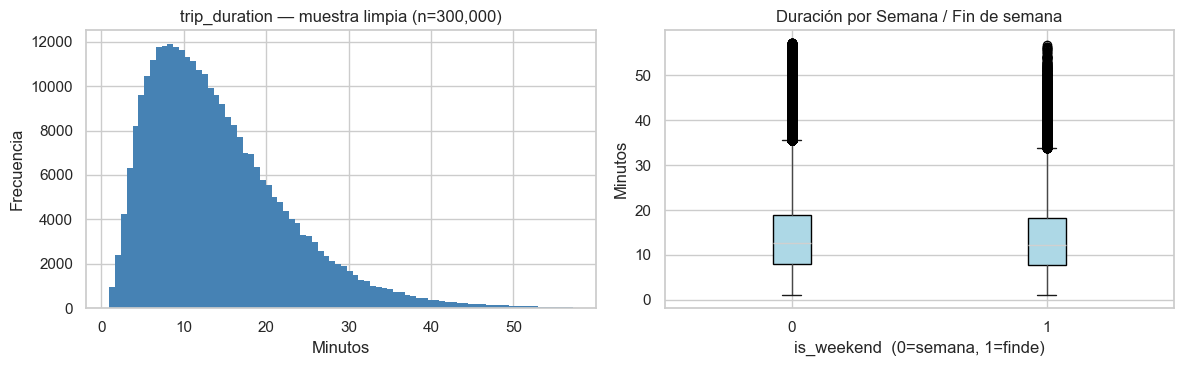

In [32]:
# Distribución final de la variable objetivo (muestra)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_sample_with_cats['trip_duration'], bins=80, color='steelblue', edgecolor='none')
axes[0].set_title(f'trip_duration — muestra limpia (n={SAMPLE_SIZE:,})')
axes[0].set_xlabel('Minutos')
axes[0].set_ylabel('Frecuencia')

df_sample_with_cats.boxplot(column='trip_duration', by='is_weekend',
                             ax=axes[1], patch_artist=True,
                             boxprops=dict(facecolor='lightblue'))
axes[1].set_title('Duración por Semana / Fin de semana')
axes[1].set_xlabel('is_weekend  (0=semana, 1=finde)')
axes[1].set_ylabel('Minutos')
plt.suptitle('')

plt.tight_layout()
plt.show()